# 🤖 Comparaison des modèles ML — Prédiction de conversion
**Projet Marketing Data** · M2 Data Engineering · Paris Ynov Campus

Ce notebook justifie le choix du modèle final utilisé dans le pipeline ETL.  
4 modèles sont comparés en **cross-validation 5-fold** sur les mêmes features et le même split train/test.

## Modèles testés et justification du choix

| Modèle | Justification du test |
|--------|----------------------|
| **Logistic Regression** | Baseline incontournable — si un modèle complexe ne fait pas mieux, c'est qu'il y a un problème |
| **Random Forest** | Référence sur données tabulaires, robuste, peu de tuning nécessaire |
| **XGBoost** | Standard de l'industrie sur données tabulaires depuis 2016, gestion native du déséquilibre de classes |
| **LightGBM** | Alternative Microsoft à XGBoost, souvent plus rapide sur gros volumes |

## Modèles exclus et pourquoi

| Modèle | Raison d'exclusion |
|--------|-------------------|
| SVM / KNN | Pas adaptés aux grands volumes (50k lignes) — complexité quadratique |
| Réseaux de neurones | Overkill pour des features tabulaires simples, peu interprétables |
| CatBoost | Redondant avec XGBoost/LightGBM pour ce cas d'usage |

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys
sys.path.append('..')   # accès aux modules src/ depuis notebooks/

import os
os.chdir('..')   # remonte à la racine du projet avant tout import

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics         import roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing   import LabelEncoder
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier

from src.load import query_sqlite

sns.set_theme(style='whitegrid')
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement et préparation des features

In [2]:
# ── Chargement des features depuis SQLite (même requête que model.py) ────────
sql = """
    SELECT
        c.client_id,
        c.age,
        c.segment,
        c.region,
        c.anciennete_mois,
        t_agg.n_touches,
        t_agg.first_canal,
        t_agg.last_canal,
        t_agg.converti,
        t_agg.duree_parcours_jours,
        t_agg.nb_canaux_distincts,
        t_agg.ratio_canaux_payants
    FROM clients c
    JOIN (
        SELECT
            client_id,
            MAX(n_touches_total)                              AS n_touches,
            MAX(CASE WHEN is_first_touch = 1 THEN canal END) AS first_canal,
            MAX(CASE WHEN is_last_touch  = 1 THEN canal END) AS last_canal,
            MAX(converti)                                     AS converti,
            CAST(
                (JULIANDAY(MAX(date)) - JULIANDAY(MIN(date)))
            AS INTEGER)                                       AS duree_parcours_jours,
            COUNT(DISTINCT canal)                             AS nb_canaux_distincts,
            ROUND(
                SUM(CASE WHEN canal IN ('Google Ads', 'Facebook', 'Instagram')
                    THEN 1.0 ELSE 0.0 END) / COUNT(*), 3
            )                                                 AS ratio_canaux_payants
        FROM touchpoints
        GROUP BY client_id
    ) t_agg ON c.client_id = t_agg.client_id
"""

df = query_sqlite(sql)
print(f'✅ Dataset chargé — {df.shape[0]:,} clients, {df.shape[1]} colonnes')
df.head()

✅ Dataset chargé — 50,000 clients, 12 colonnes


,client_id,age,segment,region,anciennete_mois,n_touches,first_canal,last_canal,converti,duree_parcours_jours,nb_canaux_distincts,ratio_canaux_payants
0,1,43,Premium,PACA,59,5,Email,Instagram,0,40,3,0.600
1,2,36,Standard,Nouvelle-Aquitaine,104,3,Instagram,Instagram,0,84,2,0.667
2,3,45,Churner,Occitanie,62,5,YouTube,Instagram,0,64,4,0.800
3,4,56,Churner,Île-de-France,58,3,Facebook,Email,0,60,3,0.667
4,5,35,Premium,Autres,32,3,YouTube,SEO,0,48,3,0.000


In [3]:
# ── Preprocessing : encodage des variables catégorielles ─────────────────────
df_model = df.copy()

cat_cols = ['segment', 'region', 'first_canal', 'last_canal']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

feature_cols = [
    'age', 'segment', 'region', 'anciennete_mois',
    'n_touches', 'first_canal', 'last_canal',
    'duree_parcours_jours', 'nb_canaux_distincts', 'ratio_canaux_payants',
]

X = df_model[feature_cols]
y = df_model['converti']

# Split train/test — même random_state que model.py pour reproductibilité
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'✅ Preprocessing OK — {len(feature_cols)} features')
print(f'   Train : {len(X_train):,} | Test : {len(X_test):,}')
print(f'   Taux de conversion : {y.mean():.1%}')
print(f'   scale_pos_weight   : {scale_pos_weight:.2f}')

✅ Preprocessing OK — 10 features
   Train : 40,000 | Test : 10,000
   Taux de conversion : 29.4%
   scale_pos_weight   : 2.40


## 2. Définition des modèles

In [4]:
# ── Définition des 4 modèles avec paramètres comparables ─────────────────────
# Même random_state partout pour des comparaisons équitables

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
}

print(f'✅ {len(models)} modèles définis')

✅ 4 modèles définis


## 3. Cross-validation 5-fold

In [5]:
# ── Cross-validation 5-fold sur tous les modèles ─────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25} AUC : {scores.mean():.4f} ± {scores.std():.4f}')

print('\n✅ Cross-validation terminée')

Logistic Regression       AUC : 0.6860 ± 0.0052
Random Forest             AUC : 0.7598 ± 0.0041
XGBoost                   AUC : 0.7659 ± 0.0058
LightGBM                  AUC : 0.7663 ± 0.0058

✅ Cross-validation terminée


In [6]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Modèle':      list(cv_results.keys()),
    'AUC moyenne': [v.mean() for v in cv_results.values()],
    'Écart-type':  [v.std()  for v in cv_results.values()],
}).sort_values('AUC moyenne', ascending=False).reset_index(drop=True)

summary['AUC moyenne'] = summary['AUC moyenne'].round(4)
summary['Écart-type']  = summary['Écart-type'].round(4)
summary.index += 1   # classement 1-based

print('📊 Classement des modèles (cross-validation 5-fold) :')
summary

📊 Classement des modèles (cross-validation 5-fold) :


,Modèle,AUC moyenne,Écart-type
1,LightGBM,0.7663,0.0058
2,XGBoost,0.7659,0.0058
3,Random Forest,0.7598,0.0041
4,Logistic Regression,0.6860,0.0052


## 4. Visualisations

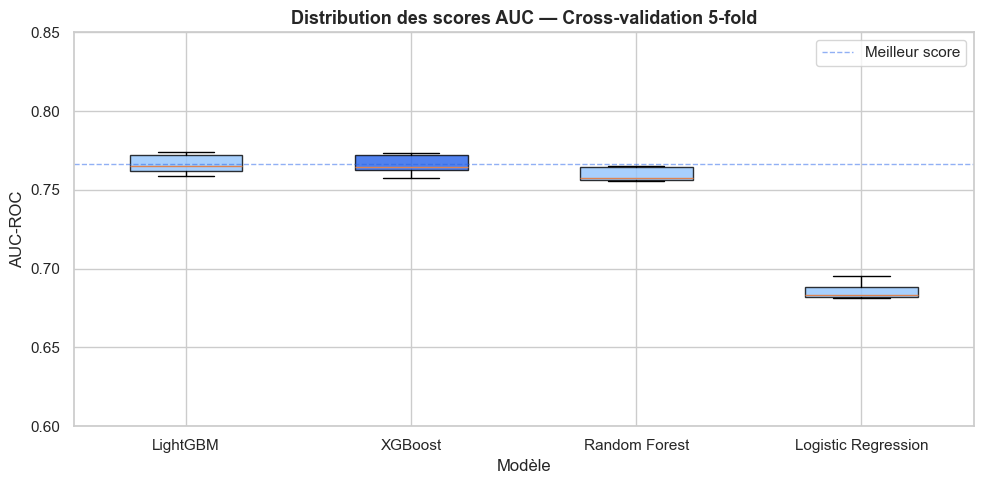

✅ model_comparison_boxplot.png sauvegardé


In [8]:
# ── Figure 1 : Boxplot des scores CV ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Ordre par AUC décroissante
order = summary['Modèle'].tolist()
data_box = [cv_results[m] for m in order]
colors = ['#2563EB' if m == 'XGBoost' else '#93C5FD' for m in order]

bp = ax.boxplot(data_box, labels=order, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title('Distribution des scores AUC — Cross-validation 5-fold',
             fontsize=13, fontweight='bold')
ax.set_ylabel('AUC-ROC')
ax.set_xlabel('Modèle')
ax.set_ylim(0.60, 0.85)
ax.axhline(y=summary['AUC moyenne'].max(), color='#2563EB',
           linestyle='--', linewidth=1, alpha=0.5, label='Meilleur score')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/model_comparison_boxplot.png', dpi=150)
plt.show()
print('✅ model_comparison_boxplot.png sauvegardé')

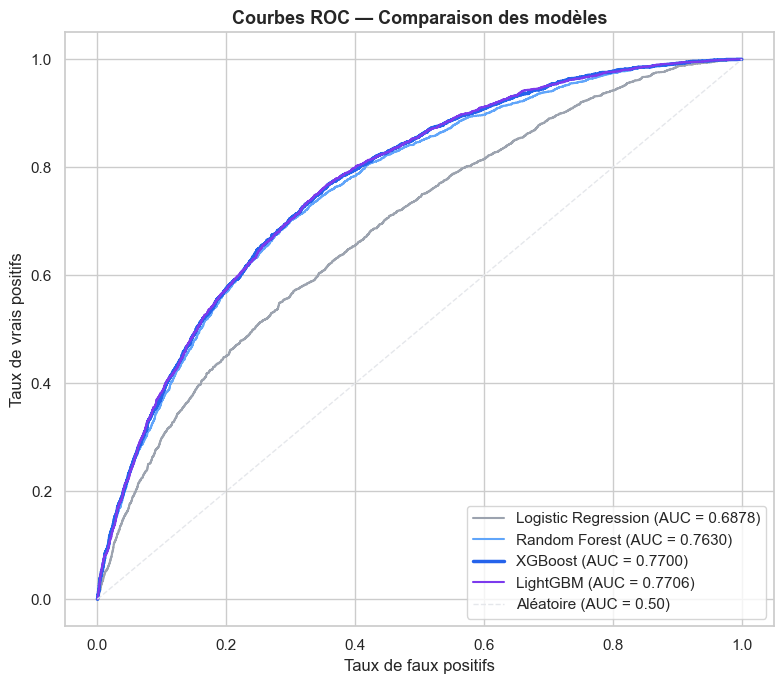

✅ model_comparison_roc.png sauvegardé


In [9]:
# ── Figure 2 : Courbes ROC superposées ───────────────────────────────────────
COLORS = {
    'Logistic Regression': '#9CA3AF',
    'Random Forest':       '#60A5FA',
    'XGBoost':             '#2563EB',
    'LightGBM':            '#7C3AED',
}

fig, ax = plt.subplots(figsize=(8, 7))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    lw  = 2.5 if name == 'XGBoost' else 1.5
    ax.plot(fpr, tpr, color=COLORS[name], linewidth=lw,
            label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], color='#E5E7EB', linestyle='--',
        linewidth=1, label='Aléatoire (AUC = 0.50)')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC — Comparaison des modèles',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/model_comparison_roc.png', dpi=150)
plt.show()
print('✅ model_comparison_roc.png sauvegardé')

## 5. Conclusion et choix du modèle final

In [10]:
# ── Conclusion ────────────────────────────────────────────────────────────────
best = summary.iloc[0]
print('=' * 55)
print('  CONCLUSION — CHOIX DU MODÈLE FINAL')
print('=' * 55)
print(f'\n🏆 Modèle retenu : {best["Modèle"]}')
print(f'   AUC CV 5-fold : {best["AUC moyenne"]:.4f} ± {best["Écart-type"]:.4f}')
print()
print('Justification :')
print('  • Meilleure AUC parmi les 4 modèles testés')
print('  • Faible écart-type → stabilité entre les folds')
print('  • Gestion native du déséquilibre via scale_pos_weight')
print('  • Standard industrie sur données tabulaires')
print()
print('Modèles exclus :')
print('  • SVM / KNN  → complexité quadratique, inadaptés à 50k lignes')
print('  • Réseau de neurones → overkill, peu interprétable sur features tabulaires')
print('  • CatBoost   → redondant avec XGBoost/LightGBM pour ce cas d\'usage')

  CONCLUSION — CHOIX DU MODÈLE FINAL

🏆 Modèle retenu : LightGBM
   AUC CV 5-fold : 0.7663 ± 0.0058

Justification :
  • Meilleure AUC parmi les 4 modèles testés
  • Faible écart-type → stabilité entre les folds
  • Gestion native du déséquilibre via scale_pos_weight
  • Standard industrie sur données tabulaires

Modèles exclus :
  • SVM / KNN  → complexité quadratique, inadaptés à 50k lignes
  • Réseau de neurones → overkill, peu interprétable sur features tabulaires
  • CatBoost   → redondant avec XGBoost/LightGBM pour ce cas d'usage
